# 03 · Regression family (leak-free)

OLS, a non-linear OLS with a `d×fcm` interaction, and Lasso/Ridge/ElasticNet — all as **pipelines** (scaler refit inside each fold) with hyper-parameters tuned by nested CV. We show a single leak-free split for intuition, then the honest cross-validated numbers from `results/`.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import punching_shear as ps
REPO = Path(ps.__file__).resolve().parent.parent
RESULTS = REPO / 'results'
ds = ps.load_dataset()
print(f'{len(ds)} tests, {ds.groups.nunique()} researchers, features={ds.feature_names}')

336 tests, 55 researchers, features=['d', 'col_area', 'rho_l', 'fcm_cyl', 'u0_perim']


### Single leak-free 70/30 split (illustration)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.base import clone
models = ps.build_models()
reg = ['OLS','NLR (d x fcm)','Lasso','Ridge','ElasticNet']
Xtr,Xte,ytr,yte = train_test_split(ds.X, ds.y_stress, test_size=.3, random_state=19)
out=[]
for name in reg:
    est=clone(models[name]).fit(Xtr,ytr)
    m=ps.regression_metrics(yte, est.predict(Xte)); m['model']=name; out.append(m)
display(pd.DataFrame(out)[['model','rmse','mae','r2','mape_pct']].round(3))

,model,rmse,mae,r2,mape_pct
0,OLS,0.306,0.230,0.586,15.284
1,NLR (d x fcm),0.318,0.238,0.554,15.506
2,Lasso,0.306,0.230,0.587,15.261
3,Ridge,0.305,0.229,0.588,15.249
4,ElasticNet,0.305,0.230,0.587,15.259


### Standardized OLS coefficients (interpretable importance)
Because features are standardized in the pipeline, coefficient magnitude is a fair importance measure — on the **stress** target.

,std. coef
fcm_cyl,0.304
rho_l,0.240
d,-0.110
u0_perim,-0.099
col_area,0.033


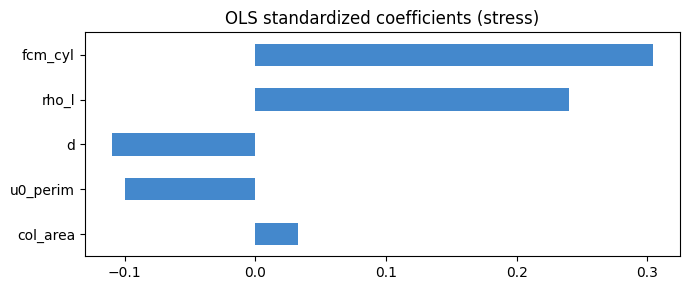

In [3]:
ols = clone(models['OLS']).fit(ds.X, ds.y_stress)
coef = pd.Series(ols.named_steps['lr'].coef_, index=ds.feature_names).sort_values(key=abs, ascending=False)
display(coef.round(3).to_frame('std. coef'))
coef.plot.barh(figsize=(7,3), color='#48c'); plt.gca().invert_yaxis(); plt.title('OLS standardized coefficients (stress)'); plt.tight_layout(); plt.show()

### Honest cross-validated comparison (from `results/`)

In [4]:
rand = pd.read_csv(RESULTS/'metrics_random_kfold.csv')
cols=['model','rmse_mean','rmse_ci95','r2_mean','mape_pct_mean']
display(rand[rand.model.isin(reg)][cols].round(4))

,model,rmse_mean,rmse_ci95,r2_mean,mape_pct_mean
2,NLR (d x fcm),0.2848,0.0131,0.6804,14.3093
3,OLS,0.2878,0.0142,0.6750,14.3264
4,Ridge,0.2879,0.0142,0.6750,14.3320
5,ElasticNet,0.2882,0.0143,0.6743,14.3538
6,Lasso,0.2883,0.0143,0.6742,14.3592


**Takeaway.** Regularization (Lasso/Ridge/ElasticNet) does **not** beat plain OLS here — with only 5 well-conditioned features there is little to shrink. The `d×fcm` interaction gives a marginal gain. All linear models land around RMSE ≈ 0.29 MPa (R² ≈ 0.68).